# URL Phishing Detection (Colab)
Train and evaluate a URL phishing classifier.

Label mapping: `1 = phishing`, `0 = legitimate`.

In [ ]:
# Optional in Colab
# !pip -q install tensorflow scikit-learn pandas matplotlib seaborn

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, MultiHeadAttention, Add, LayerNormalization, GlobalAveragePooling1D

backend_path = Path('../backend').resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))
from services.preprocess import extract_url_features

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [ ]:
# Colab upload (run in Colab only)
# from google.colab import files
# files.upload()

url_csv = Path('../phishing url.csv')
if not url_csv.exists():
    url_csv = Path('../../phishing url.csv')

df = pd.read_csv(url_csv)
if 'URL' not in df.columns:
    raise ValueError("Expected 'URL' column in phishing url.csv for backend feature extraction parity.")

y = pd.to_numeric(df['label'], errors='coerce').fillna(0).astype(int).values
X = np.vstack([extract_url_features(u)[0] for u in df['URL'].fillna('')]).astype('float32')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Total rows: {len(df)} | Train rows: {len(X_train)} | Test rows: {len(X_test)}')

# Self-attention over per-feature tokens
inp = Input(shape=(X_train.shape[1],))
x = Reshape((X_train.shape[1], 1))(inp)
x = Dense(32)(x)
attn = MultiHeadAttention(num_heads=4, key_dim=8)(x, x)
x = Add()([x, attn])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)
model = Model(inp, out)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Total rows: 235795 | Train rows: 188636 | Test rows: 47159


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 19, 1)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 19, 32)    │         64 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 19, 32)    │      4,224 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 19, 32)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 19, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,953 (23.25 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.9500 - loss: 0.1285 - val_accuracy: 0.9795 - val_loss: 0.0603
Epoch 2/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.9790 - loss: 0.0609 - val_accuracy: 0.9759 - val_loss: 0.0621
Epoch 3/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9814 - loss: 0.0536 - val_accuracy: 0.9837 - val_loss: 0.0450
Epoch 4/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.9839 - loss: 0.0469 - val_accuracy: 0.9843 - val_loss: 0.0410
Epoch 5/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.9864 - loss: 0.0409 - val_accuracy: 0.9870 - val_loss: 0.0418
Epoch 6/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 48s 18ms/step - accuracy: 0.9868 - loss: 0.0392 - val_accuracy: 0.9871 - val_loss: 0.0374
Epoch 7/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 80s 17ms/step - accuracy: 0.9872 - loss: 0.0376 - val_accuracy: 0.9853 - val_loss: 0.0370
Epoch 8/10
2653/2653 ━━━━━━━━━━━━━━━━━━━━ 46s 17ms/step - accuracy: 0.9878 -

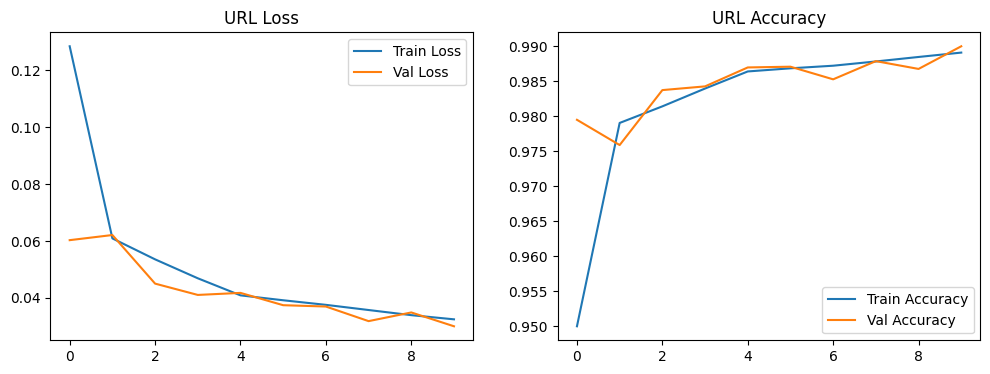

Final Train Accuracy: 0.9891
Final Val Accuracy: 0.99


In [5]:
hist = model.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=64, verbose=1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.title('URL Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
plt.title('URL Accuracy')
plt.legend()
plt.show()

print('Final Train Accuracy:', round(hist.history['accuracy'][-1], 4))
print('Final Val Accuracy:', round(hist.history['val_accuracy'][-1], 4))

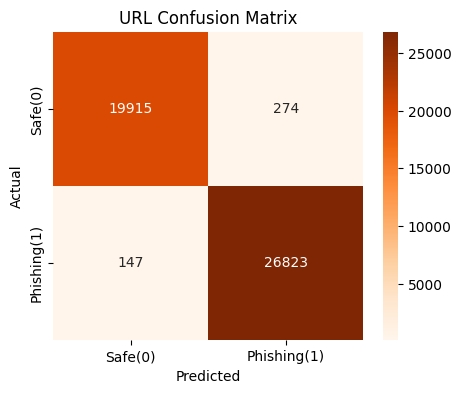

Accuracy : 0.9911
Precision: 0.9899
Recall   : 0.9945
F1-score : 0.9922
Saved: ../backend/models/url_model.h5


In [6]:
proba = model.predict(X_test, verbose=0).ravel()
pred = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred, labels=[0,1])
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, zero_division=0)
rec = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Safe(0)','Phishing(1)'], yticklabels=['Safe(0)','Phishing(1)'])
plt.title('URL Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Accuracy :', round(acc, 4))
print('Precision:', round(prec, 4))
print('Recall   :', round(rec, 4))
print('F1-score :', round(f1, 4))

from pathlib import Path
artifact_root = Path('../backend')
(artifact_root / 'models').mkdir(parents=True, exist_ok=True)

model.save(artifact_root / 'models' / 'url_model.h5')
print('Saved: ../backend/models/url_model.h5')